In [7]:
import pandas_datareader as pdr
import joypy
import pandas as pd
import datetime
import plotly.express as px
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.options.mode.chained_assignment = None

In [11]:
start_date = datetime.datetime(2014,1,1)
end_date   = datetime.datetime(2022,12,31)

In [13]:
ticker_list = ['SP500']
df = pdr.DataReader(ticker_list,
                    'fred',
                    start_date,
                    end_date)

In [15]:
df.to_csv('SP500_' + str(start_date.date()) + '_'
          + str(end_date.date())+ '.csv')

In [21]:
df.to_pickle('SP500_' + str(start_date.date()) +'_'
             +str(end_date.date()) + '.pkl')

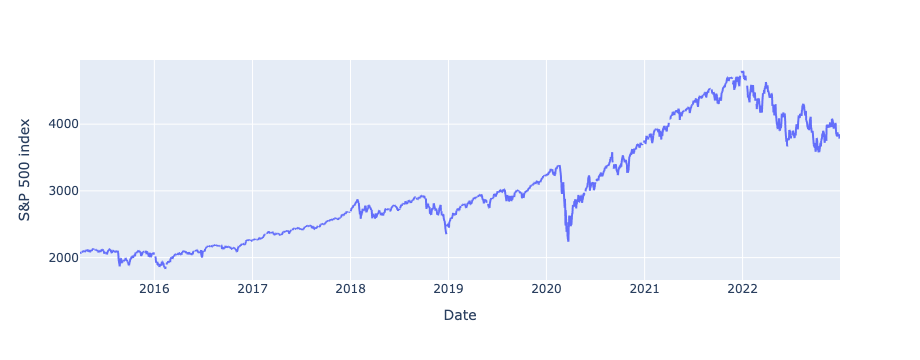

In [27]:
fig = px.line(df)
fig.update_layout(xaxis_title = 'Date',
                  yaxis_title = 'S&P 500 index',
                  legend_title = 'Curve',
                  showlegend = False)
fig.show()

In [33]:
percentag_missing = df.isnull().sum()*100/len(df)
print('Percentage of missing data')
print("%.3f%%" % (percentag_missing))

Percentage of missing data
3.457%


/var/folders/f0/8_68v87s7qg9dj06g39mn0gh0000gn/T/ipykernel_57393/650220847.py:3: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead



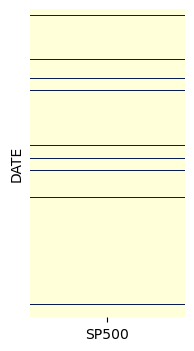

In [39]:
fig,ax = plt.subplots(figsize = (2,4))
sns.heatmap(df.isnull(),cbar = False,
            cmap = 'YlGnBu',yticklabels = [])
plt.show()

In [69]:
df_ = df.dropna()
percentag_missing = df_.isnull().sum()*100/len(df)
print('Percentage of missing data')
print("%.3f %%" % percentag_missing)

Percentage of missing data
0.000 %


/var/folders/f0/8_68v87s7qg9dj06g39mn0gh0000gn/T/ipykernel_57393/4249030029.py:4: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead



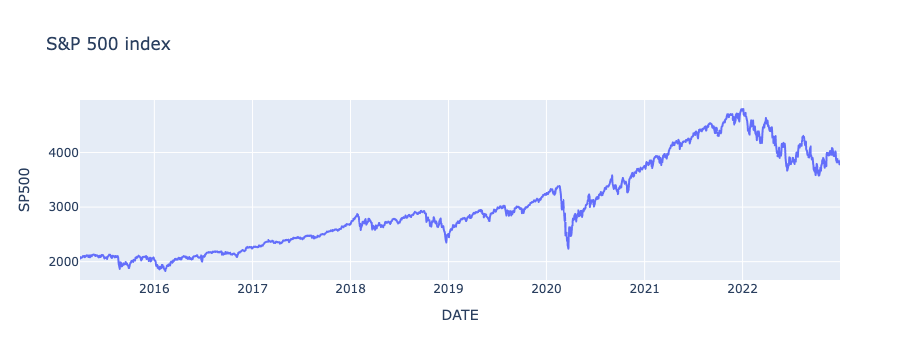

In [71]:
fig = px.line(df_,y='SP500',title = 'S&P 500 index')
fig.show()

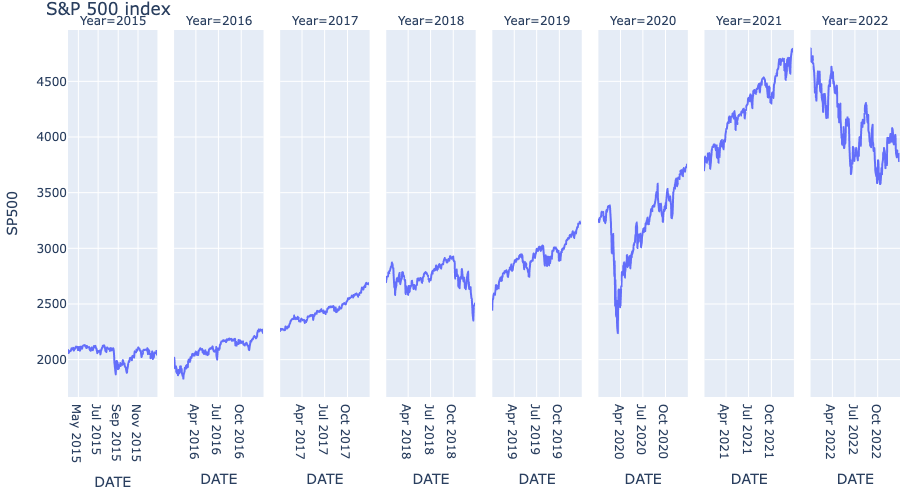

In [75]:
df_['Year']=pd.DatetimeIndex(df_.index).year
fig = px.line(df_,y = 'SP500',title = 'S&P 500 index',
              facet_col = 'Year',facet_row=None)

fig.update_layout(
    width = 700,
    height = 500,
    margin=dict(l=20,r=20,t=30,b=20),
    paper_bgcolor="white")
fig.update_xaxes(matches=None)
fig.show()

In [77]:
df_['MA20'] = df_['SP500'].rolling(20).mean() #rolling仅仅表示
df_['MA10'] = df_['SP500'].rolling(10).mean()
df_['MA5'] = df_['SP500'].rolling(5).mean()

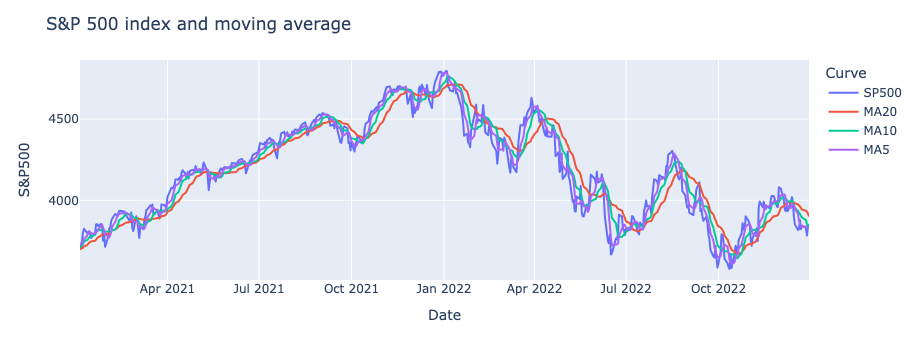

In [79]:
fig = px.line(df_[['SP500','MA20','MA10','MA5']].loc['20210101':'20221231'])
fig.update_layout(title = 'S&P 500 index and moving average',
                  xaxis_title = 'Date',
                  yaxis_title = 'S&P500',
                  legend_title = 'Curve')

fig.show()

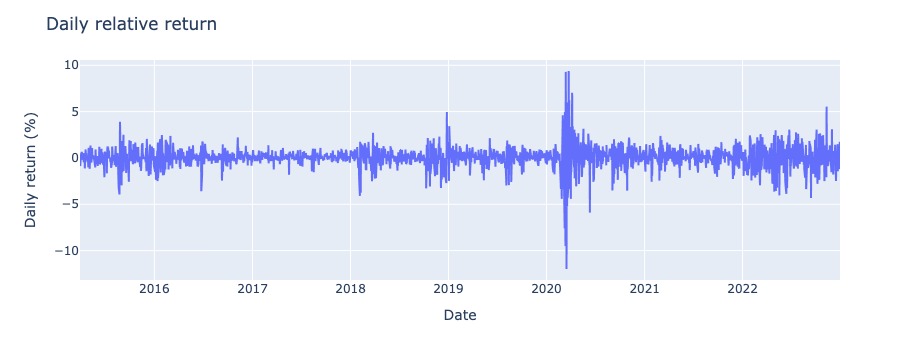

In [81]:
df_['daily_r'] = df_['SP500'].pct_change()*100

fig = px.line(df_,y = 'daily_r')
fig.update_layout(title = 'Daily relative return',
                  xaxis_title = 'Date',
                  yaxis_title = 'Daily return (%)',
                  legend_title = 'Curve')

fig.show()

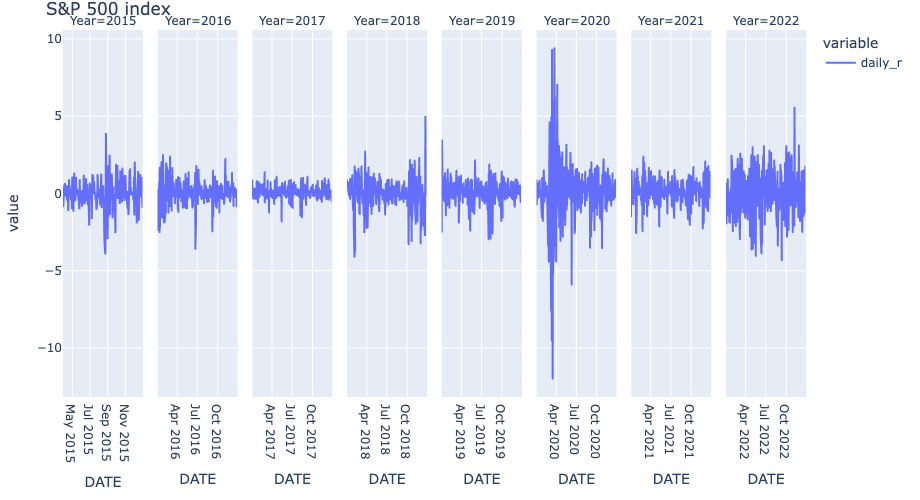

In [95]:
fig = px.line(df_,y = ['daily_r'],title = 'S&P 500 index',
              facet_col='Year',facet_row=None)

fig.update_layout(
    width = 700,
    height = 500,
    margin = dict(l=20,r=20,t=30,b=20),
    paper_bgcolor='white')
fig.update_xaxes(matches = None)

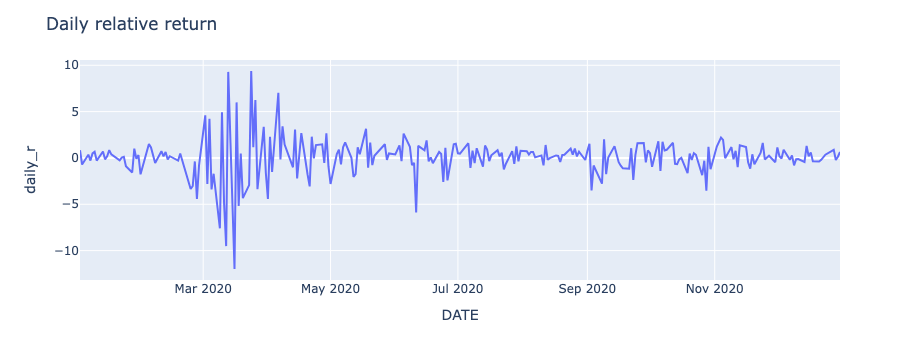

In [97]:
fig = px.line(df_['20200101':'20201231'],y='daily_r')
fig.update_layout(title = 'Daily relative return')
fig.show()

In [101]:
mean = np.mean(df_['daily_r'])
mean

0.03840725872317395

In [103]:
df_['daily_r'].mean()

0.03840725872317395

In [105]:
std = np.std(df_['daily_r'])
std

1.1957599120281093

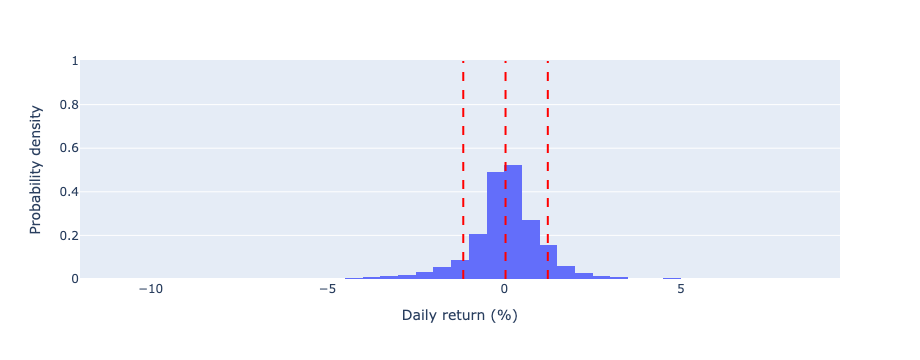

In [133]:
fig = px.histogram(df_['daily_r'],nbins = 50,
                   histnorm = 'probability density')
fig.add_shape(type='line',x0=mean,y0=0,x1=mean,y1=1,
              line=dict(color='red',dash='dash'),name='mean')

fig.add_shape(type='line',x0=mean+std,y0=0,x1=mean+std,y1=1,
              line=dict(color='red',dash='dash'),name='mean+std') #默认为虚线
fig.add_shape(type='line',x0=mean-std,y0=0,x1=mean-std,y1=1,
              line=dict(color='red',dash='dash'),name='mean+std')

fig.update_layout(showlegend=False,
                  xaxis_title = 'Daily return (%)',
                  yaxis_title = 'Probability density')

fig.show()

In [135]:
df_.columns

Index(['SP500', 'Year', 'MA20', 'MA10', 'MA5', 'daily_r'], dtype='object')

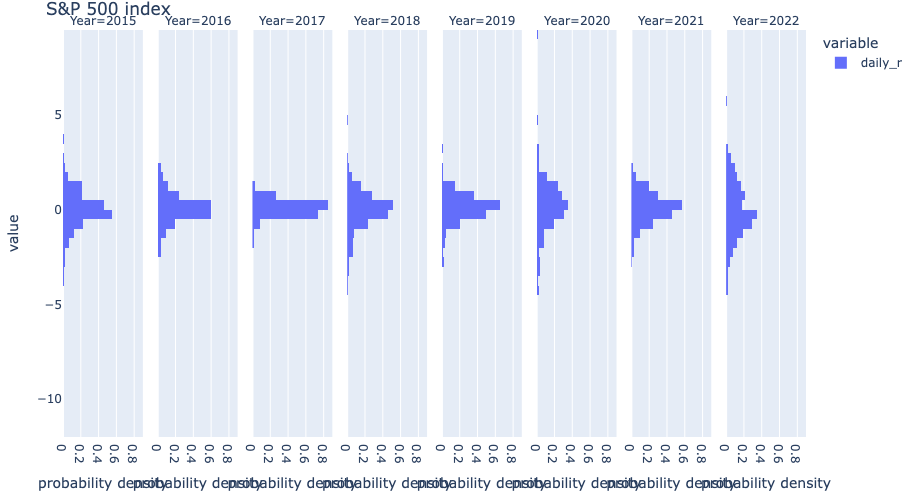

In [139]:
fig = px.histogram(df_[['daily_r','Year']],nbins = 80,
                   histnorm='probability density',
                   title = 'S&P 500 index',
                   orientation = 'h',
                   facet_col='Year',facet_row=None)
fig.update_layout(
    width = 1200,
    height=500,
    margin=dict(l=20,r=20,t=30,b=20),
    paper_bgcolor="white")
fig.update_xaxes(matches='x')
fig.show()